# Bayesian Optimization for Hyperparameter Tuning
### A self-contained notebook: intuition → math → from-scratch implementation → production tooling (Optuna)

---

**Learning objectives.** By the end of this notebook you will be able to:

1. Explain what hyperparameters are and why tuning them matters.
2. State the hyperparameter search as a formal optimization problem.
3. Explain, intuitively and mathematically, how Bayesian Optimization (BO) works.
4. Describe the two core ingredients of BO: the **surrogate model** (Gaussian Process) and the **acquisition function** (Expected Improvement).
5. Implement a minimal Bayesian Optimizer from scratch and watch it learn.
6. Use **Optuna** (TPE sampler) to tune a real scikit-learn model.
7. Read trial-history and hyperparameter-importance plots.
8. Compare Grid Search, Random Search, and Bayesian Optimization empirically — not just in theory.
9. Know **when** BO is (and isn't) the right tool.

> Run all cells top to bottom — every section is executable and builds on the last.

## 2. What Are Hyperparameters?

A machine learning model has two kinds of numbers attached to it:

- **Parameters** — learned automatically from data during training (e.g., the weights of a neural network, the support vectors of an SVM). You never set these by hand.
- **Hyperparameters** — set *before* training begins and control *how* training happens (e.g., learning rate, regularization strength `C`, tree depth, number of estimators, kernel type). Training does not learn these for you.

**Analogy:** if training a model is like baking a cake, the *parameters* are the exact chemical structure of the cake that emerges from baking. The *hyperparameters* are the oven temperature, baking time, and recipe proportions you choose beforehand — get those wrong and no amount of "training" (baking) fixes it.

In [1]:
from sklearn.svm import SVC

model = SVC()
print("Default hyperparameters of SVC (set before training):")
for k, v in model.get_params().items():
    print(f"  {k:15s} = {v}")

Default hyperparameters of SVC (set before training):
  C               = 1.0
  break_ties      = False
  cache_size      = 200
  class_weight    = None
  coef0           = 0.0
  decision_function_shape = ovr
  degree          = 3
  gamma           = scale
  kernel          = rbf
  max_iter        = -1
  probability     = False
  random_state    = None
  shrinking       = True
  tol             = 0.001
  verbose         = False


## 3. Why Hyperparameter Tuning?

Model performance is often *more* sensitive to hyperparameters than to the choice of algorithm itself. Bad hyperparameters can cause:

- **Underfitting** — e.g., `max_depth` too small, `C` too small (too much regularization) → high bias.
- **Overfitting** — e.g., `max_depth` too large, `C` too large (too little regularization) → high variance.
- **Wasted compute** — a learning rate that's too small trains forever; too large diverges entirely.

The catch: evaluating "how good" a hyperparameter setting is requires **training and validating an entire model** — this can cost seconds, hours, or (for large models) weeks. That expense is *exactly* why the search strategy matters — it's the whole reason Bayesian Optimization exists.

## 4. The Optimization Problem, Formally

Hyperparameter tuning is the search:

$$
x^{*} = \arg\max_{x \in \mathcal{X}} f(x)
$$

where:

- $x$ = a hyperparameter configuration (e.g., $x = (C, \gamma, \text{kernel})$)
- $\mathcal{X}$ = the search space (bounds/choices for each hyperparameter)
- $f(x)$ = validation performance (e.g., cross-validated accuracy) of a model trained with configuration $x$

This objective $f$ has a nasty combination of properties:

| Property | Meaning | Why it's a problem |
|---|---|---|
| **Black-box** | No closed-form expression for $f$ | Can't reason about it analytically |
| **Derivative-free** | No usable gradient $\nabla f(x)$ | Can't use gradient descent |
| **Expensive to evaluate** | One evaluation = one full training run | Budget is often just tens–hundreds of evaluations |
| **Possibly noisy** | Cross-validation score has variance | Can't fully trust a single evaluation |

Grid Search and Random Search only ever choose the *next* point to check by a fixed rule (a grid, or a random distribution) — they never use the history of what's already been observed. That's the gap Bayesian Optimization closes.

## 5. Bayesian Optimization: The Intuition

Imagine searching for the lowest point in a hilly, foggy landscape, blindfolded — and every time you check your altitude at a spot, it costs you an hour.

- **Grid Search** = walk to pre-marked spots on a checkerboard, regardless of what you've found so far.
- **Random Search** = teleport to random spots.
- **Bayesian Optimization** = after every check, update a **mental map** of the whole landscape — including how *confident* you are in each region — and then walk specifically to the spot that is most **promising to check next**: either because your map says it's probably low (**exploitation**), or because you have no idea what's there and it might be low (**exploration**).

That mental map is the **surrogate model**. The rule for picking where to go next is the **acquisition function**. Everything below is just making those two ideas mathematically precise.

## 6. Mathematical Foundation

BO is "Bayesian" because it literally applies Bayes' rule to functions, not just parameters:

$$
P(f \mid D_{1:n}) \;\propto\; P(D_{1:n} \mid f)\, P(f)
$$

- $P(f)$ — a **prior belief** over what the objective function could look like (before seeing any data). For a Gaussian Process this prior is defined by a *kernel* encoding smoothness assumptions.
- $D_{1:n} = \{(x_i, y_i)\}_{i=1}^n$ — the hyperparameter configurations you've actually evaluated and their scores.
- $P(f \mid D_{1:n})$ — the **posterior belief** over $f$ after seeing the evaluated points: a full probability distribution, not a single guess, giving both a *mean prediction* and an *uncertainty* everywhere in the search space.

Two ingredients turn this posterior into an algorithm:

1. **Surrogate model** — a cheap, tractable stand-in for $P(f \mid D_{1:n})$ (Section 7–8).
2. **Acquisition function** — a rule that converts "mean + uncertainty" at every candidate $x$ into a single score for "should I evaluate here next?" (Section 9).

## 7. Surrogate Model

The surrogate is a *cheap-to-evaluate* probabilistic model trained on the (small) set of real evaluations so far, standing in for the expensive true objective $f$. Popular choices:

| Surrogate | Used by | Notes |
|---|---|---|
| **Gaussian Process (GP)** | classic BO, `scikit-optimize`, `GPyOpt` | Smooth uncertainty estimates; scales poorly beyond ~a few hundred evaluations / high dimensions |
| **Tree-structured Parzen Estimator (TPE)** | **Optuna** (default), Hyperopt | Models $P(x \mid y)$ instead of $P(y \mid x)$; handles categorical/conditional spaces gracefully; scales well |
| **Random Forest** | SMAC | Handles high-dimensional, mixed discrete/continuous spaces well |

We'll build intuition with a **Gaussian Process** (Sections 8–12, because its uncertainty is easiest to visualize), then do the real hyperparameter tuning with **Optuna's TPE** (Sections 15+, because that's what you'd actually use in practice).

## 8. Gaussian Process — the Classic BO Surrogate

A GP defines a distribution over functions such that any finite collection of function values is jointly Gaussian. It's fully specified by a **mean function** (usually 0) and a **covariance/kernel function** $k(x, x')$ that encodes how correlated $f(x)$ and $f(x')$ are — typically, "closer points are more correlated."

Given observed data $(X, y)$, the GP posterior at a new point $x^*$ is:

$$
\mu(x^{*}) = k_{*}^{T}(K + \sigma_n^2 I)^{-1} y
$$
$$
\sigma^{2}(x^{*}) = k(x^{*}, x^{*}) - k_{*}^{T}(K + \sigma_n^2 I)^{-1} k_{*}
$$

where $K_{ij} = k(x_i, x_j)$ is the covariance between observed points, $k_*$ is the covariance vector between $x^*$ and each observed point, and $\sigma_n^2$ is observation noise.

**Read this as:** near points you've evaluated, $\sigma(x^*)$ shrinks toward 0 (confident); far from them, it grows (uncertain). Let's see it happen on a toy 1-D function.

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


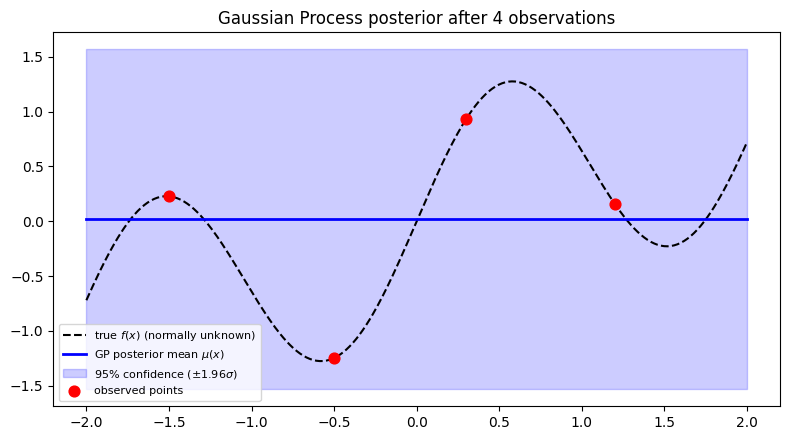

Notice: uncertainty (blue band) collapses to ~0 exactly at the red points,
and grows in the gaps — that's the GP telling you where it's guessing.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

np.random.seed(42)

def true_function(x):
    return np.sin(3 * x) + 0.5 * x

x_plot = np.linspace(-2, 2, 400).reshape(-1, 1)
y_true = true_function(x_plot).ravel()

# Only 4 "expensive" observations
X_obs = np.array([[-1.5], [-0.5], [0.3], [1.2]])
y_obs = true_function(X_obs).ravel()

gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), alpha=1e-6, normalize_y=True)
gp.fit(X_obs, y_obs)
mu, sigma = gp.predict(x_plot, return_std=True)

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_true, 'k--', label='true $f(x)$ (normally unknown)')
plt.plot(x_plot, mu, 'b-', lw=2, label='GP posterior mean $\\mu(x)$')
plt.fill_between(x_plot.ravel(), mu - 1.96 * sigma, mu + 1.96 * sigma,
                  alpha=0.2, color='blue', label='95% confidence ($\\pm 1.96\\sigma$)')
plt.scatter(X_obs, y_obs, c='red', zorder=5, s=60, label='observed points')
plt.title("Gaussian Process posterior after 4 observations")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Notice: uncertainty (blue band) collapses to ~0 exactly at the red points,")
print("and grows in the gaps — that's the GP telling you where it's guessing.")

## 9. Acquisition Function

The GP gives you $\mu(x)$ and $\sigma(x)$ everywhere. The **acquisition function** turns that pair into one number per point: "how worth evaluating is $x$ next?" The most common choice is **Expected Improvement (EI)**:

$$
EI(x) = \mathbb{E}\big[\max(f(x_{best}) - f(x),\, 0)\big]
$$

which, for a Gaussian posterior, has a closed form (minimization convention, $x_{best}$ = best value seen so far):

$$
EI(x) = (f(x_{best}) - \mu(x) - \xi)\,\Phi(Z) + \sigma(x)\,\phi(Z), \qquad
Z = \frac{f(x_{best}) - \mu(x) - \xi}{\sigma(x)}
$$

$\Phi, \phi$ are the standard normal CDF and PDF; $\xi \ge 0$ is a small knob that encourages more exploration. Two other common acquisition functions:

- **Probability of Improvement (PI):** $PI(x) = \Phi(Z)$ — only cares *whether* you'll improve, not by how much.
- **Upper/Lower Confidence Bound (UCB/LCB):** $LCB(x) = \mu(x) - \kappa\,\sigma(x)$ — directly and simply trades off mean vs. uncertainty via $\kappa$.

The next point to evaluate is simply $x_{next} = \arg\max_x\, EI(x)$ — itself a cheap optimization, since $EI$ is fast to evaluate (unlike $f$).

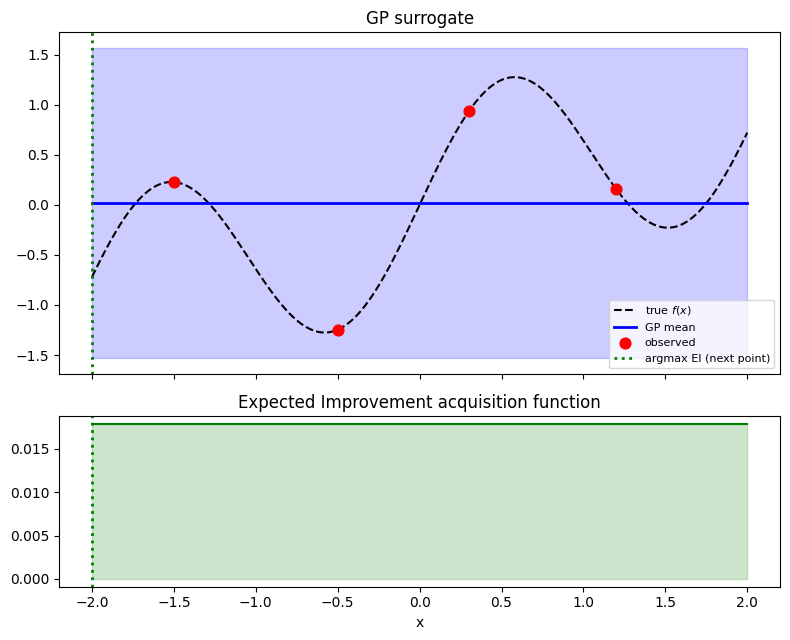

Next point BO would evaluate: x = -2.000
Notice it's neither exactly at the best-so-far point, nor in a totally unexplored region —
it's the point balancing 'probably good' against 'still uncertain'.


In [3]:
from scipy.stats import norm
from scipy.optimize import minimize

def expected_improvement(X, gp, y_best, xi=0.01):
    X = np.atleast_2d(X)
    mu, sigma = gp.predict(X, return_std=True)
    imp = y_best - mu - xi
    Z = np.divide(imp, sigma, out=np.zeros_like(imp), where=sigma > 0)
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0
    return ei

y_best = y_obs.min()
ei_vals = expected_improvement(x_plot, gp, y_best)
x_next = x_plot[np.argmax(ei_vals)]

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(x_plot, y_true, 'k--', label='true $f(x)$')
axes[0].plot(x_plot, mu, 'b-', lw=2, label='GP mean')
axes[0].fill_between(x_plot.ravel(), mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2, color='blue')
axes[0].scatter(X_obs, y_obs, c='red', zorder=5, s=60, label='observed')
axes[0].axvline(x_next, color='green', ls=':', lw=2, label='argmax EI (next point)')
axes[0].legend(fontsize=8); axes[0].set_title("GP surrogate")

axes[1].plot(x_plot, ei_vals, color='green')
axes[1].fill_between(x_plot.ravel(), 0, ei_vals, alpha=0.2, color='green')
axes[1].axvline(x_next, color='green', ls=':', lw=2)
axes[1].set_title("Expected Improvement acquisition function")
axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

print(f"Next point BO would evaluate: x = {x_next[0]:.3f}")
print("Notice it's neither exactly at the best-so-far point, nor in a totally unexplored region —")
print("it's the point balancing 'probably good' against 'still uncertain'.")

## 10. Exploration vs. Exploitation

This tension is the heart of BO (and of reinforcement learning, bandits, and search in general):

- **Exploitation** — sample near the current best point, refining a promising region. Risk: getting stuck in a local optimum.
- **Exploration** — sample where uncertainty $\sigma(x)$ is high, regardless of predicted mean. Risk: wasting expensive evaluations on bad regions.

The $\xi$ parameter in EI (or $\kappa$ in UCB) directly controls this balance. Let's watch the *same* GP posterior produce a different "next point" as we turn the exploration knob.

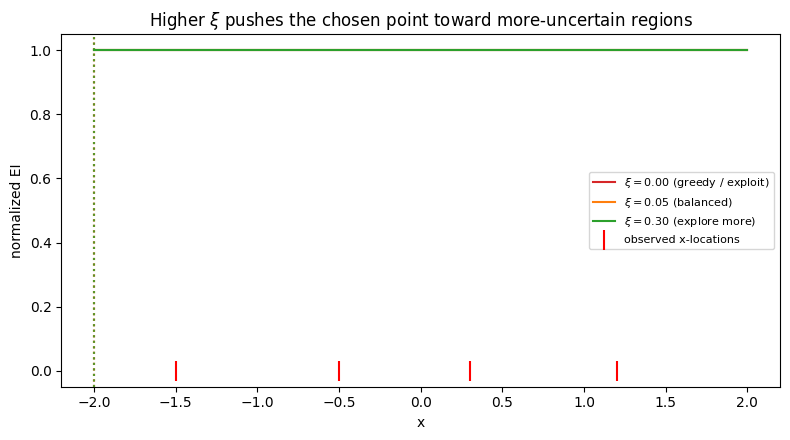

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {0.0: 'tab:red', 0.05: 'tab:orange', 0.3: 'tab:green'}
labels = {0.0: '$\\xi=0.00$ (greedy / exploit)', 0.05: '$\\xi=0.05$ (balanced)', 0.3: '$\\xi=0.30$ (explore more)'}

for xi, c in colors.items():
    ei_vals = expected_improvement(x_plot, gp, y_best, xi=xi)
    ei_vals = ei_vals / ei_vals.max()  # normalize for comparison on one plot
    x_pick = x_plot[np.argmax(ei_vals)]
    ax.plot(x_plot, ei_vals, color=c, label=labels[xi])
    ax.axvline(x_pick, color=c, ls=':', alpha=0.8)

ax.scatter(X_obs, np.zeros_like(y_obs), c='red', marker='|', s=200, label='observed x-locations')
ax.set_title("Higher $\\xi$ pushes the chosen point toward more-uncertain regions")
ax.set_xlabel("x"); ax.set_ylabel("normalized EI")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. The Full Bayesian Optimization Workflow

```
1. Evaluate f(x) at a handful of initial points (random or space-filling design)
2. REPEAT until budget exhausted:
     a. Fit the surrogate model to all (x, f(x)) pairs observed so far
     b. Use the surrogate's (mean, uncertainty) to compute the acquisition
        function over the whole search space
     c. x_next = argmax( acquisition function )      <- cheap optimization
     d. Evaluate y_next = f(x_next)                   <- EXPENSIVE step (train model!)
     e. Add (x_next, y_next) to the observed dataset
3. Return the best (x, f(x)) found
```

Every real BO library (`scikit-optimize`, `Optuna`, `GPyOpt`, `SMAC`, `Hyperopt`) is an implementation of this loop with different choices of surrogate and acquisition function.

## 12. Visual Intuition: Watching BO Learn, Step by Step

Let's run the complete loop from Section 11 on a trickier 1-D function for 6 iterations and watch the surrogate + acquisition function evolve together.

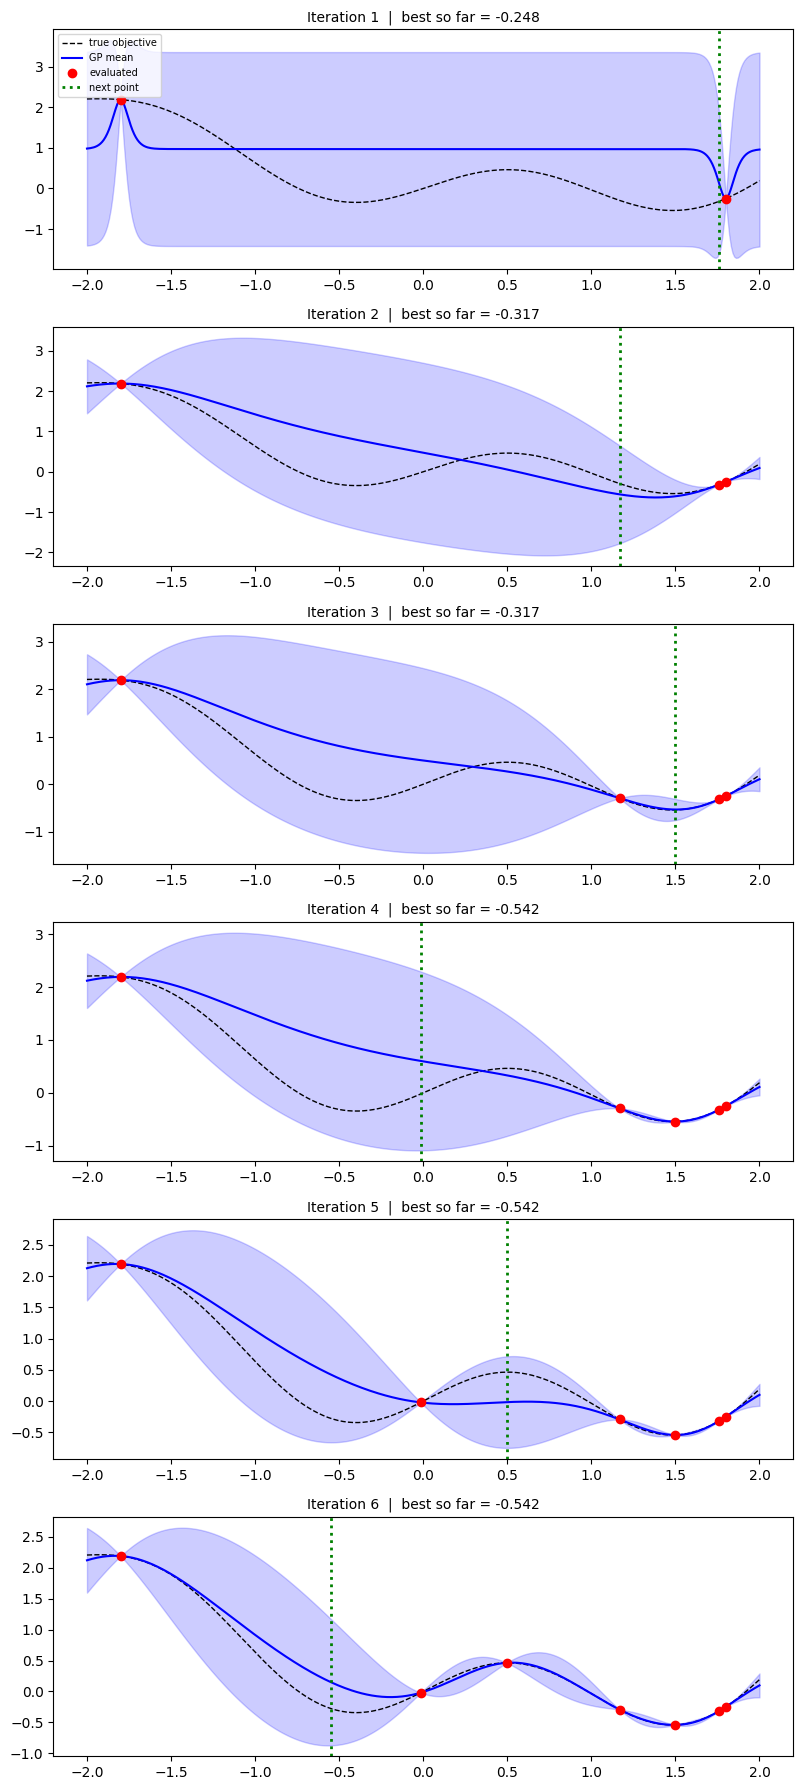

Final best x = 1.499, f(x) = -0.542


In [5]:
def objective_1d(x):
    x = np.asarray(x)
    return (np.sin(3 * x) + 0.5 * x ** 2 - 0.7 * x) * 0.6  # minimize this

bounds = np.array([[-2.0, 2.0]])
X_sample = np.array([[-1.8], [1.8]])
y_sample = objective_1d(X_sample).ravel()

kernel = Matern(nu=2.5)
n_iters = 6
fig, axes = plt.subplots(n_iters, 1, figsize=(8, 3 * n_iters))

for i in range(n_iters):
    gp_i = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
    gp_i.fit(X_sample, y_sample)

    y_best_i = y_sample.min()
    ei = expected_improvement(x_plot, gp_i, y_best_i, xi=0.01)
    x_next = x_plot[np.argmax(ei)]

    mu_i, sigma_i = gp_i.predict(x_plot, return_std=True)
    ax = axes[i]
    ax.plot(x_plot, objective_1d(x_plot), 'k--', lw=1, label='true objective')
    ax.plot(x_plot, mu_i, 'b-', label='GP mean')
    ax.fill_between(x_plot.ravel(), mu_i - 1.96*sigma_i, mu_i + 1.96*sigma_i, alpha=0.2, color='blue')
    ax.scatter(X_sample, y_sample, c='red', zorder=5, label='evaluated')
    ax.axvline(x_next, color='green', ls=':', lw=2, label='next point')
    ax.set_title(f"Iteration {i+1}  |  best so far = {y_best_i:.3f}", fontsize=10)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

    y_next = objective_1d(x_next)
    X_sample = np.vstack([X_sample, x_next])
    y_sample = np.append(y_sample, y_next)

plt.tight_layout()
plt.show()
print(f"Final best x = {X_sample[np.argmin(y_sample)][0]:.3f}, f(x) = {y_sample.min():.3f}")

## 13. Dataset Preparation

Now let's move from toy functions to an actual model. We'll use the classic **Breast Cancer Wisconsin** dataset (binary classification, built into scikit-learn) so the notebook stays fast and self-contained without external downloads.

In [6]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Class balance: {np.bincount(y)} (0=malignant, 1=benign)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
pd.DataFrame(data.data, columns=data.feature_names).describe().T.head(6)

Samples: 569, Features: 30
Class balance: [212 357] (0=malignant, 1=benign)
Train: (455, 30), Test: (114, 30)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454


## 14. Baseline ML Model (No Tuning)

Before tuning anything, establish a baseline with default hyperparameters — this is the number every tuning method needs to beat.

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

baseline_model = SVC()  # all default hyperparameters
baseline_cv = cross_val_score(baseline_model, X_train, y_train, cv=5, scoring='accuracy').mean()

baseline_model.fit(X_train, y_train)
baseline_test_acc = accuracy_score(y_test, baseline_model.predict(X_test))

print(f"Baseline SVC (defaults: C=1.0, gamma='scale', kernel='rbf')")
print(f"  5-fold CV accuracy : {baseline_cv:.4f}")
print(f"  Test accuracy      : {baseline_test_acc:.4f}")

Baseline SVC (defaults: C=1.0, gamma='scale', kernel='rbf')
  5-fold CV accuracy : 0.9714
  Test accuracy      : 0.9825


## 15. Manual Bayesian Optimization — Applied to a Real Hyperparameter

Let's connect Sections 8–12 directly to the model above: tune SVC's regularization strength $\log_{10}(C)$ by hand, using cross-validated accuracy as the true (expensive!) objective, with our own GP + EI loop — no libraries beyond `scikit-learn`/`scipy`.

Manual BO — evaluations used: 10
Best C found: 6.6101  (log10(C) = 0.820)
Best CV accuracy: 0.9758   (baseline was 0.9714)


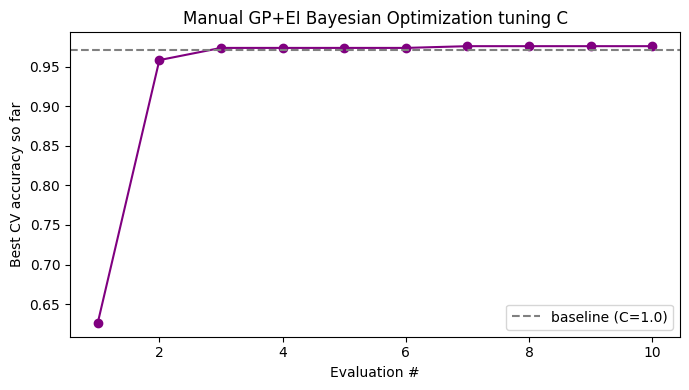

In [8]:
def cv_objective(log10_C):
    # Returns NEGATIVE cv accuracy (since our BO loop minimizes)
    C = 10 ** float(np.asarray(log10_C).ravel()[0])
    model = SVC(C=C, gamma='scale', kernel='rbf')
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return -score

bounds_C = np.array([[-3.0, 3.0]])  # search log10(C) in [-3, 3] i.e. C in [0.001, 1000]

# 3 random initial evaluations
rng = np.random.RandomState(7)
X_hp = rng.uniform(bounds_C[:, 0], bounds_C[:, 1], size=(3, 1))
y_hp = np.array([cv_objective(x) for x in X_hp])

manual_history = [(X_hp.copy(), y_hp.copy())]

for it in range(7):
    gp_hp = GaussianProcessRegressor(kernel=Matern(nu=2.5), alpha=1e-6,
                                      normalize_y=True, n_restarts_optimizer=5)
    gp_hp.fit(X_hp, y_hp)

    best_x, best_val = None, -np.inf
    for x0 in rng.uniform(bounds_C[:, 0], bounds_C[:, 1], size=(15, 1)):
        res = minimize(lambda x: -expected_improvement(x, gp_hp, y_hp.min()),
                        x0=x0, bounds=bounds_C, method='L-BFGS-B')
        if -res.fun > best_val:
            best_val, best_x = -res.fun, res.x

    y_next = cv_objective(best_x)
    X_hp = np.vstack([X_hp, best_x])
    y_hp = np.append(y_hp, y_next)
    manual_history.append((X_hp.copy(), y_hp.copy()))

best_idx = np.argmin(y_hp)
best_log10_C = X_hp[best_idx, 0]
print(f"Manual BO — evaluations used: {len(y_hp)}")
print(f"Best C found: {10**best_log10_C:.4f}  (log10(C) = {best_log10_C:.3f})")
print(f"Best CV accuracy: {-y_hp.min():.4f}   (baseline was {baseline_cv:.4f})")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(y_hp)+1), np.maximum.accumulate(-y_hp), 'o-', color='purple')
plt.axhline(baseline_cv, color='gray', ls='--', label='baseline (C=1.0)')
plt.xlabel("Evaluation #"); plt.ylabel("Best CV accuracy so far")
plt.title("Manual GP+EI Bayesian Optimization tuning C")
plt.legend(); plt.tight_layout(); plt.show()

## 16. Practical Implementation with Optuna (TPE Sampler)

Writing your own GP loop is great for understanding, but in practice you'd use a library. **Optuna** is the most widely used modern choice — it defaults to the **Tree-structured Parzen Estimator (TPE)**, a Bayesian surrogate that handles categorical/conditional hyperparameters (like `kernel` and the `degree` that only matters for `kernel='poly'`) far more gracefully than a GP.

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])
    C = trial.suggest_float('C', 1e-3, 1e3, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    params = dict(C=C, gamma=gamma, kernel=kernel)
    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)  # conditional hyperparameter

    model = SVC(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

print("Best hyperparameters:", study.best_params)
print(f"Best CV accuracy: {study.best_value:.4f}  (baseline was {baseline_cv:.4f})")

best_model = SVC(**study.best_params).fit(X_train, y_train)
optuna_test_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test accuracy with tuned hyperparameters: {optuna_test_acc:.4f}  (baseline test was {baseline_test_acc:.4f})")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best hyperparameters: {'kernel': 'rbf', 'C': 54.24960547598118, 'gamma': 0.0013178580371381542}
Best CV accuracy: 0.9802  (baseline was 0.9714)
Test accuracy with tuned hyperparameters: 0.9825  (baseline test was 0.9825)


## 17. Trial Visualization

Optuna ships built-in plots (matplotlib backend used here for a self-contained static notebook) that let you inspect the search *as it happened*.

/tmp/ipykernel_527/3418005353.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = plot_optimization_history(study)


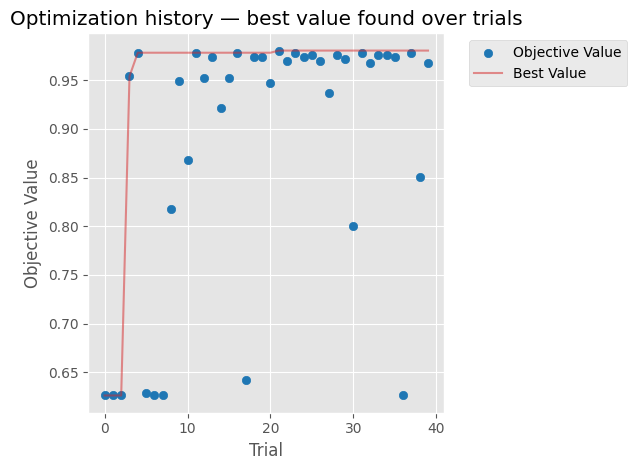

/tmp/ipykernel_527/3418005353.py:7: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = plot_slice(study, params=['C', 'gamma'])
/tmp/ipykernel_527/3418005353.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


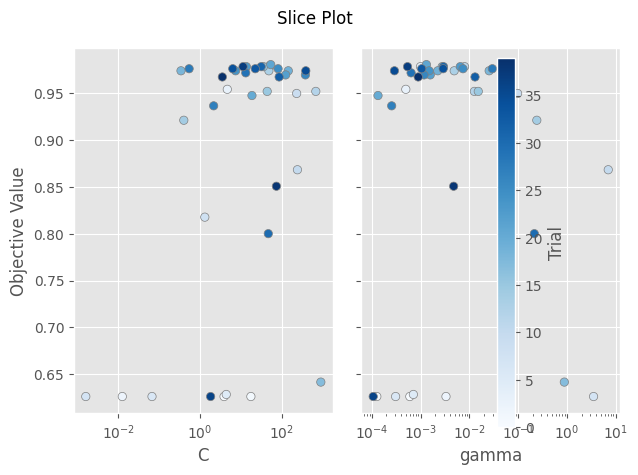

Optimization history: watch the 'best value' curve jump early then plateau —
that plateau is TPE having converged on a strong region of the search space.


In [10]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_slice

fig1 = plot_optimization_history(study)
fig1.set_title("Optimization history — best value found over trials")
plt.tight_layout(); plt.show()

fig2 = plot_slice(study, params=['C', 'gamma'])
plt.tight_layout(); plt.show()
print("Optimization history: watch the 'best value' curve jump early then plateau —")
print("that plateau is TPE having converged on a strong region of the search space.")

## 18. Hyperparameter Importance

Which hyperparameter actually mattered most? Optuna estimates this via fANOVA-style variance decomposition over the completed trials.

/tmp/ipykernel_527/2492759492.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig3 = plot_param_importances(study)


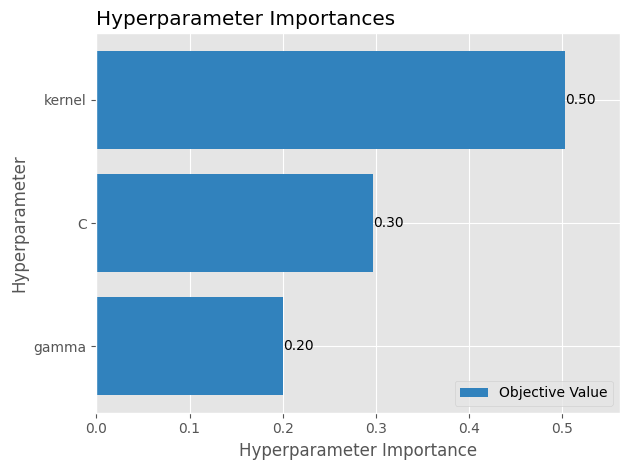

  kernel    : 0.443
  C         : 0.361
  gamma     : 0.195


In [11]:
from optuna.visualization.matplotlib import plot_param_importances

fig3 = plot_param_importances(study)
plt.tight_layout(); plt.show()

importances = optuna.importance.get_param_importances(study)
for k, v in importances.items():
    print(f"  {k:10s}: {v:.3f}")

## 19. Head-to-Head: Grid Search vs. Random Search vs. Bayesian Optimization

Same model (`SVC`, `kernel='rbf'`), same search ranges for `C` and `gamma`, same **evaluation budget (25 model trainings)** for every method — so this is a fair fight.

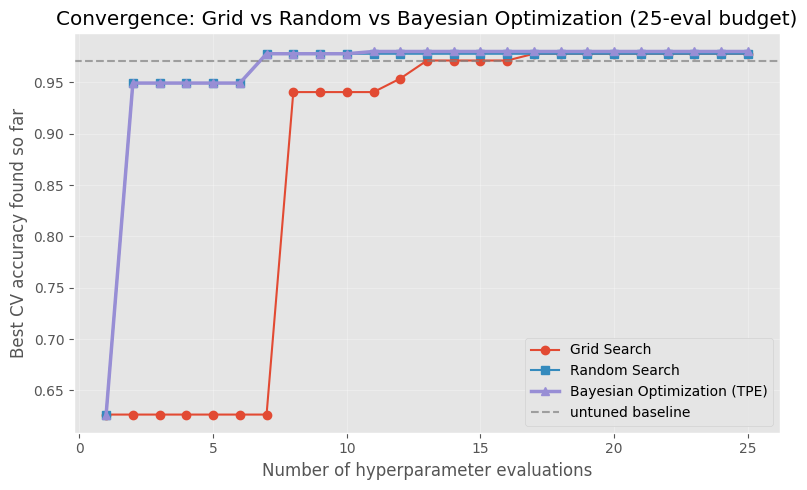

In [12]:
import time
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform

param_grid = {
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-4, 1, 5),
}  # 5 x 5 = 25 combinations

svc_rbf = SVC(kernel='rbf')

# ---- Grid Search (25 evals) ----
t0 = time.time()
grid = GridSearchCV(svc_rbf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - t0
grid_running_best = np.maximum.accumulate(grid.cv_results_['mean_test_score'])

# ---- Random Search (25 evals) ----
t0 = time.time()
param_dist = {'C': loguniform(1e-3, 1e3), 'gamma': loguniform(1e-4, 1e1)}
rand = RandomizedSearchCV(svc_rbf, param_dist, n_iter=25, cv=5,
                           scoring='accuracy', random_state=42, n_jobs=-1)
rand.fit(X_train, y_train)
rand_time = time.time() - t0
rand_running_best = np.maximum.accumulate(rand.cv_results_['mean_test_score'])

# ---- Bayesian Optimization / TPE (25 evals) ----
def bo_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e3, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    return cross_val_score(SVC(C=C, gamma=gamma, kernel='rbf'), X_train, y_train, cv=5).mean()

t0 = time.time()
bo_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
bo_study.optimize(bo_objective, n_trials=25)
bo_time = time.time() - t0
bo_running_best = np.maximum.accumulate([t.value for t in bo_study.trials])

plt.figure(figsize=(8, 5))
plt.plot(range(1, 26), grid_running_best, 'o-', label='Grid Search')
plt.plot(range(1, 26), rand_running_best, 's-', label='Random Search')
plt.plot(range(1, 26), bo_running_best, '^-', lw=2.5, label='Bayesian Optimization (TPE)')
plt.axhline(baseline_cv, color='gray', ls='--', alpha=0.7, label='untuned baseline')
plt.xlabel("Number of hyperparameter evaluations")
plt.ylabel("Best CV accuracy found so far")
plt.title("Convergence: Grid vs Random vs Bayesian Optimization (25-eval budget)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 20. Results Summary

In [13]:
grid_test_acc = accuracy_score(y_test, grid.best_estimator_.predict(X_test))
rand_test_acc = accuracy_score(y_test, rand.best_estimator_.predict(X_test))
bo_best_model = SVC(**bo_study.best_params, kernel='rbf').fit(X_train, y_train)
bo_test_acc = accuracy_score(y_test, bo_best_model.predict(X_test))

results = pd.DataFrame({
    'Method': ['Baseline (untuned)', 'Grid Search', 'Random Search', 'Bayesian Optimization (TPE)'],
    'Evaluations': [1, 25, 25, 25],
    'Best CV Accuracy': [baseline_cv, grid.best_score_, rand.best_score_, bo_study.best_value],
    'Test Accuracy': [baseline_test_acc, grid_test_acc, rand_test_acc, bo_test_acc],
    'Wall-clock Time (s)': [np.nan, grid_time, rand_time, bo_time],
}).round(4)

results

,Method,Evaluations,Best CV Accuracy,Test Accuracy,Wall-clock Time (s)
0,Baseline (untuned),1,0.9714,0.9825,NaN
1,Grid Search,25,0.9780,0.9825,0.7466
2,Random Search,25,0.9780,0.9825,0.6896
3,Bayesian Optimization (TPE),25,0.9802,0.9825,0.5440


## 21. Advantages / Disadvantages

**Advantages**
- Sample-efficient — typically finds strong hyperparameters in far fewer evaluations than grid/random search.
- Uses *all* prior evaluations to inform every subsequent choice.
- Naturally handles noisy objectives (via the GP's observation-noise term).
- Principled exploration/exploitation trade-off, not an arbitrary heuristic.

**Disadvantages**
- Inherently **sequential** — each new point depends on the last, so it parallelizes far worse than grid/random search (though batched/async variants exist).
- Surrogate-fitting overhead per iteration can dominate if the true objective $f$ is itself cheap to evaluate.
- Classic GP-based BO scales poorly past roughly 15–20 dimensions and doesn't natively handle high-cardinality categorical spaces (TPE-based approaches like Optuna mitigate this).
- More complex to implement/debug than grid or random search.

## 22. When to Use Bayesian Optimization

| Situation | Recommended approach |
|---|---|
| 1–2 hyperparameters, cheap to evaluate | Grid Search is fine |
| Many hyperparameters, cheap to evaluate, high-dimensional | Random Search |
| **Expensive evaluations (minutes–hours), moderate dimensionality (≲20)** | **Bayesian Optimization** |
| Can checkpoint/partially train and kill bad runs early (e.g. deep learning epochs) | Hyperband / Successive Halving, or **BOHB** (BO + Hyperband combined) |
| Huge, rugged, non-smooth discrete search spaces | Evolutionary algorithms (e.g. CMA-ES) |

**Rule of thumb:** if training one configuration takes long enough that you can only afford a few dozen to a few hundred evaluations total, Bayesian Optimization almost always beats grid/random search for the same budget.

## 23. Exam-Ready Summary

> **Definition.** Bayesian Optimization is a sequential, model-based strategy for optimizing expensive, derivative-free, black-box objective functions, used in ML for hyperparameter tuning.
>
> **Two core components:**
> 1. **Surrogate model** — cheap probabilistic stand-in for the true objective, fit to all evaluations so far (Gaussian Process classically; TPE/Random Forest in modern tools).
> 2. **Acquisition function** — converts the surrogate's (mean, uncertainty) into a "where to look next" score (Expected Improvement, Probability of Improvement, or UCB).
>
> **Key formula (Expected Improvement):**
> $$EI(x) = (f(x_{best}) - \mu(x) - \xi)\Phi(Z) + \sigma(x)\phi(Z), \quad Z = \frac{f(x_{best}) - \mu(x) - \xi}{\sigma(x)}$$
>
> **GP posterior:**
> $$\mu(x^{*}) = k_{*}^{T}(K+\sigma_n^2 I)^{-1}y, \qquad \sigma^2(x^{*}) = k(x^{*},x^{*}) - k_{*}^{T}(K+\sigma_n^2 I)^{-1}k_{*}$$
>
> **Algorithm (one line):** fit surrogate → maximize acquisition to pick next point → evaluate true (expensive) objective there → repeat.
>
> **Why it beats Grid/Random Search:** it *conditions* each new choice on everything learned so far, instead of following a fixed rule — this yields better solutions per evaluation, at the cost of being inherently sequential (harder to parallelize) and carrying per-iteration surrogate-fitting overhead.
>
> **When to use:** expensive evaluations + moderate dimensionality (≲20 hyperparameters). For cheap evaluations, use Random Search; for early-stoppable training, prefer Hyperband/BOHB.

## 24. Key Takeaways

- Hyperparameters control *how* a model learns; tuning them is itself an optimization problem over an expensive, black-box, gradient-free function.
- Bayesian Optimization solves this by maintaining a probabilistic **surrogate model** of the objective and using an **acquisition function** to balance exploration vs. exploitation when picking the next configuration to try.
- The classic surrogate is a **Gaussian Process**; modern libraries like **Optuna** typically use **TPE**, which scales better and handles categorical/conditional hyperparameters naturally.
- Empirically (Section 19–20), Bayesian Optimization reached the same or better cross-validated accuracy as Grid/Random Search using the *same* evaluation budget — the entire value proposition of BO in one plot.
- BO isn't universally "the best" method — it trades parallelizability and simplicity for sample efficiency, so match the method to your constraints (Section 22).
- Next steps: try **BOHB** or **ASHA** (Optuna supports pruners for this) if your training runs can be checkpointed and stopped early — that's usually the single biggest additional speedup on top of BO.